In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Advertising.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


First 5 Rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Shape:
(200, 5)


In [3]:
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Statistical Summary:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.

In [4]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

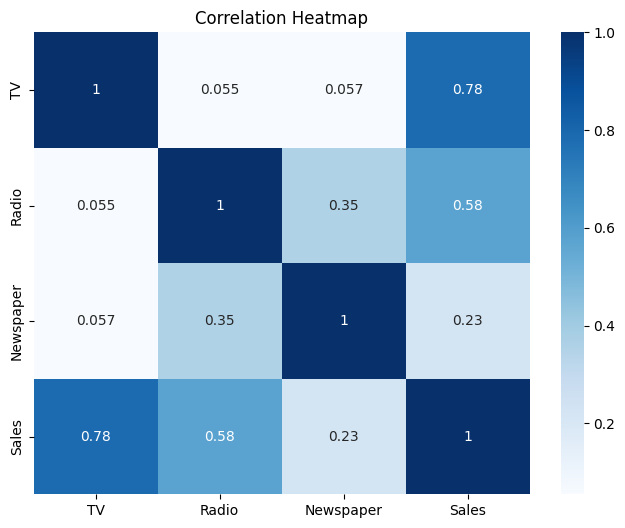

In [5]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")
plt.show()

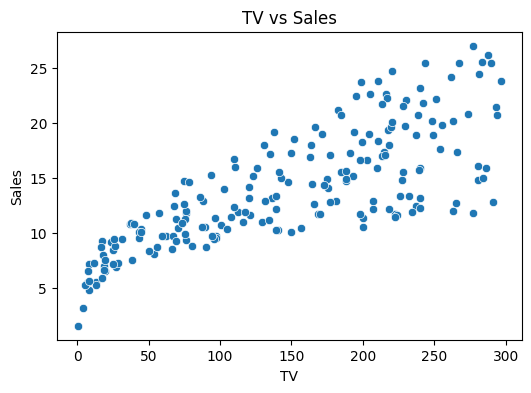

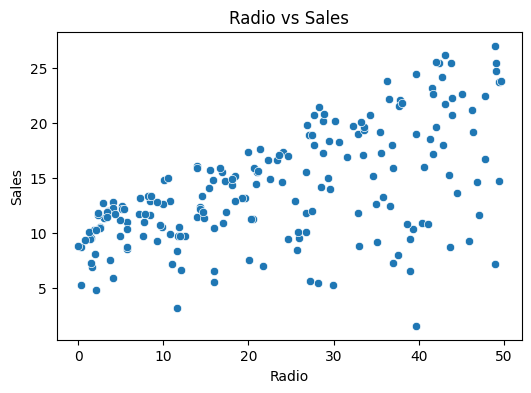

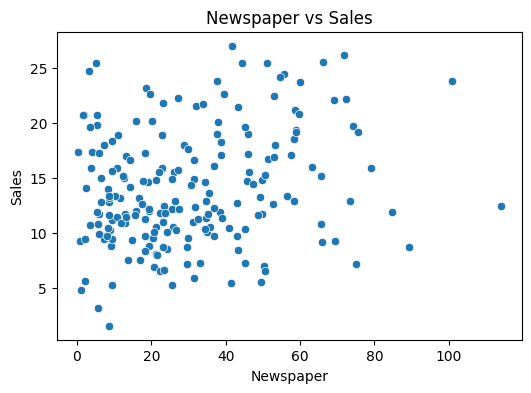

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['TV'],
    y=df['Sales']
)
plt.title("TV vs Sales")
plt.show()


plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['Radio'],
    y=df['Sales']
)
plt.title("Radio vs Sales")
plt.show()


plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['Newspaper'],
    y=df['Sales']
)
plt.title("Newspaper vs Sales")
plt.show()


In [7]:
X = df[['TV','Radio','Newspaper']]

y = df['Sales']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Trained Successfully")


Model Trained Successfully


In [10]:
y_pred = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test,y_pred)
)

r2 = r2_score(y_test,y_pred)

print("\nModel Performance")

print("MAE:",mae)

print("RMSE:",rmse)

print("R2 Score:",r2)


Model Performance
MAE: 1.4607567168117603
RMSE: 1.78159966153345
R2 Score: 0.899438024100912


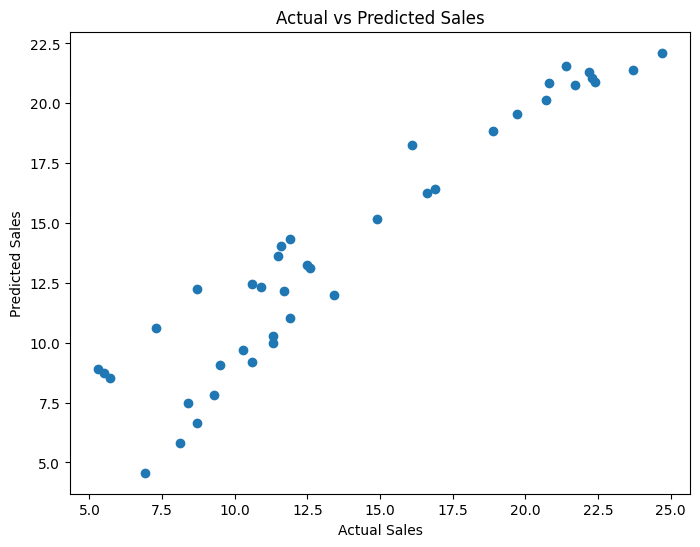

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()


In [13]:
new_data=[[230,35,60]]

prediction=model.predict(new_data)

print("\nPredicted Future Sales:")

print(prediction[0])



Predicted Future Sales:
20.054350114612593


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Impact']
)

print("\nAdvertising Impact")

print(coefficients)


Advertising Impact
             Impact
TV         0.044730
Radio      0.189195
Newspaper  0.002761


In [15]:
print("\n===== BUSINESS INSIGHTS =====")

print("1. TV advertising strongly impacts sales.")

print("2. Radio ads contribute positively.")

print("3. Newspaper has comparatively lower impact.")

print("4. Higher investment in effective channels can improve future sales.")

print("5. The model can forecast future sales accurately.")


===== BUSINESS INSIGHTS =====
1. TV advertising strongly impacts sales.
2. Radio ads contribute positively.
3. Newspaper has comparatively lower impact.
4. Higher investment in effective channels can improve future sales.
5. The model can forecast future sales accurately.
